In [ ]:
import zipfile
import pandas as pd
import os

zip_path = "/content/English.zip"
extract_folder = "/content/extracted"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

all_dfs = []

for root, dirs, files in os.walk(extract_folder):

    for file in files:

        if file.endswith(".xlsx") and "_Bianca" in file:

            file_path = os.path.join(root, file)

            adjective = file.split("_Bianca")[0]

            df = pd.read_excel(file_path)
            df["adjective"] = adjective

            all_dfs.append(df)

combined_df = pd.concat(all_dfs, ignore_index=True)

combined_df.to_excel(
    "/content/combined_Bianca.xlsx",
    index=False
)

print(combined_df.head())

              file Domain Gender  sent_index  token_id token_form token_lemma  \
0  Art12_en.conllu    Art      M          35        14  different   different   
1  Art12_en.conllu    Art      M          60        43  different   different   
2  Art13_en.conllu    Art      M          30        10  different   different   
3  Art14_en.conllu    Art      M          44         6  different   different   
4  Art14_en.conllu    Art      M          75        12  different   different   

                                            sentence EN_Evaluative?  \
0  And now it 's 2010 , and there are 99 heroes f...     Evaluative   
1  And he controls them from the top down -- wher...     Evaluative   
2  Fair enough . But I wanted interviews that wer...     Evaluative   
3  It 's about mappings between different percept...     Evaluative   
4  And so I 've been beginning , with a variety o...     Evaluative   

  EN_Attitude_type de_aligned_forms de_aligned_lemmas  \
0     Appreciation           

# Positive vs. Negative

In [ ]:
!pip install pandas openpyxl spacy

In [40]:
import pandas as pd
import spacy
from pathlib import Path

# Load English model
nlp = spacy.load("en_core_web_sm")

INPUT_FILE = "/content/combined_Bianca.xlsx"
SENTENCE_COL = "sentence"
ADJ_COL = "adjective"  # change if your column name differs

NEGATION_WORDS = {
    "not",
    "never",
    "no",
    "n't"
}


"""

NOTE:I've checked all sentences with these phrases and negators but it doesnt have any occurance of this.

NEGATION_PHRASES = {
    "no longer",
    "by no means",
    "in no way",
    "under no circumstances",
    "on no account"
}

BORDERLINE_NEGATORS = {
    "hardly",
    "barely",
    "scarcely",
    "rarely",
    "seldom"
}
"""

def is_negated_adjective(sentence, adjective):
    """
    Detect whether the target adjective is negated.
    Returns:
        (True/False, negation_type)
    """

    if pd.isna(sentence) or pd.isna(adjective):
        return False, None

    doc = nlp(str(sentence))
    adjective = str(adjective).lower()

    for token in doc:

        if token.lemma_.lower() != adjective:
            continue

        # Direct dependency negation
        for child in token.children:
            if child.dep_ == "neg":
                return True, child.text

        # Negation attached to adjective head
        if token.head:
            for child in token.head.children:
                if child.dep_ == "neg":
                    return True, child.text

        # Common negation words nearby
        window = doc[max(0, token.i - 4): min(len(doc), token.i + 5)]

        for nearby in window:
            if nearby.lower_ in NEGATION_WORDS:
                return True, nearby.text

        # "no longer"
        text = sentence.lower()
        if "no longer" in text:
            return True, "no longer"

    return False, None


def split_positive_negative(df):

    negative_rows = []
    positive_rows = []

    for _, row in df.iterrows():

        sentence = row[SENTENCE_COL]
        adjective = row[ADJ_COL]

        negated, neg_type = is_negated_adjective(
            sentence,
            adjective
        )

        row_copy = row.copy()

        if negated:
            row_copy["negation_type"] = neg_type
            negative_rows.append(row_copy)
        else:
            positive_rows.append(row_copy)

    negative_df = pd.DataFrame(negative_rows)
    positive_df = pd.DataFrame(positive_rows)

    return positive_df, negative_df


def main():

    df = pd.read_excel(INPUT_FILE)

    positive_df, negative_df = split_positive_negative(df)

    positive_df.to_excel(
        "positive.xlsx",
        index=False
    )

    negative_df.to_excel(
        "negative.xlsx",
        index=False
    )

    print(f"Positive rows: {len(positive_df)}")
    print(f"Negative rows: {len(negative_df)}")


if __name__ == "__main__":
    main()

Positive rows: 2767
Negative rows: 222


# Evaluative vs. Non-Evaluative

In [42]:
df = pd.read_excel("/content/combined_Bianca.xlsx")

In [43]:
df.columns = (
    df.columns
    .str.replace("?", "", regex=False)
    .str.strip()
    .str.replace(" ", "_")
)

In [45]:
cols = ["EN_Evaluative", "DE_Evaluative"]

for c in cols:
    df[c] = (
        df[c]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace("nan", pd.NA)
    )

### Per adjective frequencies:

* EN_eval
* EN_non_eval
* EN_eval_not_speaker
* DE equivalents

In [88]:
table_a = (
    df.groupby("adjective")
      .agg(
          total_occurrences=("adjective", "size"),

          EN_eval=("EN_Evaluative",
                   lambda x: (x == "evaluative").sum()),

          EN_non_eval=("EN_Evaluative",
                       lambda x: (x == "non-evaluative").sum()),

          EN_eval_not_speaker=("EN_Evaluative",
                               lambda x: (x == "evaluative-not_speaker").sum()),

          DE_eval=("DE_Evaluative",
                   lambda x: (x == "evaluative").sum()),

          DE_non_eval=("DE_Evaluative",
                       lambda x: (x == "non-evaluative").sum()),

          DE_eval_not_speaker=("DE_Evaluative",
                               lambda x: (x == "evaluative-not_speaker").sum())
      )
      .reset_index()
)
table_a

,adjective,total_occurrences,EN_eval,EN_non_eval,EN_eval_not_speaker,DE_eval,DE_non_eval,DE_eval_not_speaker
0,amazing,123,120,0,3,118,2,3
1,bad,251,201,8,42,194,17,39
2,beautiful,73,61,2,9,60,3,9
3,creative,56,37,12,7,36,13,7
4,different,394,378,1,15,355,21,15
5,difficult,65,56,0,8,57,1,6
6,good,848,676,111,59,662,125,56
7,happy,121,39,6,76,40,9,71
8,important,248,222,1,25,216,6,26
9,incredible,53,53,0,0,51,1,0


Overall EN evaluativity distribution.

In [89]:
table_b = (
    df["EN_Evaluative"]
    .value_counts(dropna=False)
    .rename_axis("EN_Evaluative_Status")
    .reset_index(name="Count")
)

table_b["Percentage"] = (
    table_b["Count"]
    / table_b["Count"].sum()
    * 100
).round(2)

### Overall DE evaluativity distribution.

In [60]:
table_b_de = (
    df["DE_Evaluative"]
    .value_counts(dropna=False)
    .rename_axis("DE_Evaluative_Status")
    .reset_index(name="Count")
)

table_b_de["Percentage"] = (
    table_b_de["Count"]
    / table_b_de["Count"].sum()
    * 100
).round(2)

table_b_de

,DE_Evaluative_Status,Count,Percentage
0,evaluative,2345,78.45
1,non-evaluative,327,10.94
2,evaluative-not_speaker,294,9.84
3,<NA>,17,0.57
4,uncertain,6,0.20


In [75]:
eval_df = df[
    df["EN_Evaluative"] != "non-evaluative"
]

### Overall English Attitude types.

In [76]:
table_c = (
    eval_df["EN_Attitude_type"]
    .value_counts()
    .rename_axis("Attitude")
    .reset_index(name="Count")
)

table_c["Percentage"] = (
    table_c["Count"]
    / table_c["Count"].sum()
    * 100
).round(2)

table_c

,Attitude,Count,Percentage
0,Appreciation,2178,78.88
1,Judgement,438,15.86
2,Affect,128,4.64
3,Uncertain,17,0.62


### Attitude × evaluativity source (speaker vs not-speaker).

In [70]:
table_c1 = pd.crosstab(
    eval_df["EN_Attitude_type"],
    eval_df["EN_Evaluative"]
)

table_c1

EN_Evaluative,evaluative,evaluative-not_speaker
EN_Attitude_type,,
Affect,38,90
Appreciation,2018,160
Judgement,377,61
Uncertain,17,0


### Overall Attitude Distribution

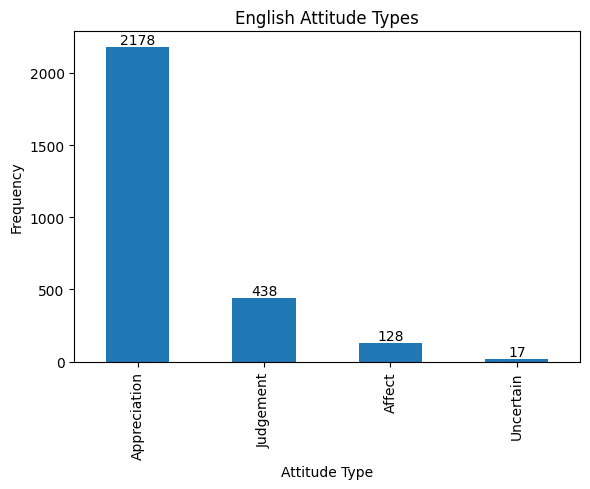

In [83]:
import matplotlib.pyplot as plt

counts = (
    eval_df["EN_Attitude_type"]
    .value_counts()
)

plt.figure(figsize=(6, 5))

counts.plot(kind="bar")

#adding count values on top of the bars
for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.ylabel("Frequency")
plt.xlabel("Attitude Type")
plt.title("English Attitude Types")

plt.tight_layout()
plt.savefig("graph1_attitude_distribution.png",dpi = 1200)

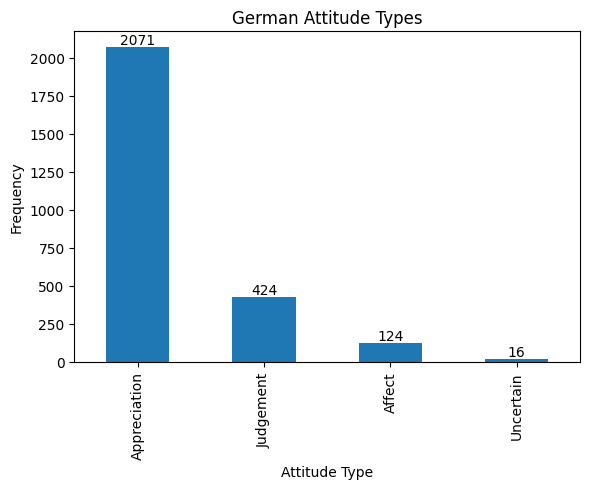

In [84]:
import matplotlib.pyplot as plt

counts = (
    eval_df["DE_Attitude_type"]
    .value_counts()
)

plt.figure(figsize=(6, 5))

counts.plot(kind="bar")

#adding count values on top of the bars
for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.ylabel("Frequency")
plt.xlabel("Attitude Type")
plt.title("German Attitude Types")

plt.tight_layout()
plt.savefig("graph1_attitude_distribution_DE.png",dpi = 1200)

### Attitude Distribution per Adjective

In [77]:
attitude_by_adj = pd.crosstab(
    eval_df["adjective"],
    eval_df["EN_Attitude_type"]
)

In [118]:
# ============================================================
# EN Attitude Type Distribution — Per Adjective
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Filter: EN evaluative rows only (same logic as eval_df) ---
en_att_df = df[df["EN_Evaluative"] != "non-evaluative"].copy()
en_att_df = en_att_df[en_att_df["EN_Attitude_type"].notna()]

# --- TABLE: Raw counts ---
en_att_per_adj = (
    en_att_df
    .groupby(["adjective", "EN_Attitude_type"])
    .size()
    .unstack(fill_value=0)
    .rename_axis(columns=None)
    .reset_index()
)

# Add row totals
en_att_per_adj["Total_Evaluative"] = en_att_per_adj.drop(columns="adjective").sum(axis=1)

print("=== EN Attitude Type per Adjective (Raw Counts) ===")
print(en_att_per_adj.to_string(index=False))

# --- TABLE: Row percentages ---
att_cols = [c for c in en_att_per_adj.columns if c not in ("adjective", "Total_Evaluative")]

en_att_pct = en_att_per_adj[["adjective", "Total_Evaluative"]].copy()
for col in att_cols:
    en_att_pct[col + "_%"] = (
        en_att_per_adj[col] / en_att_per_adj["Total_Evaluative"] * 100
    ).round(1)

print("\n=== EN Attitude Type per Adjective (Row %) ===")
print(en_att_pct.to_string(index=False))


=== EN Attitude Type per Adjective (Raw Counts) ===
  adjective  Affect  Appreciation  Judgement  Uncertain  Total_Evaluative
    amazing       0           103         20          0               123
        bad       9           199         33          2               243
  beautiful       0            60         10          0                70
   creative       0            16         28          0                44
  different       3           354         35          1               393
  difficult       0            63          0          1                64
       good      10           546        171          8               735
      happy     102            13          0          0               115
  important       0           241          6          0               247
 incredible       0            50          3          0                53
interesting       0           124          5          0               129
      right       2           262         55          0     

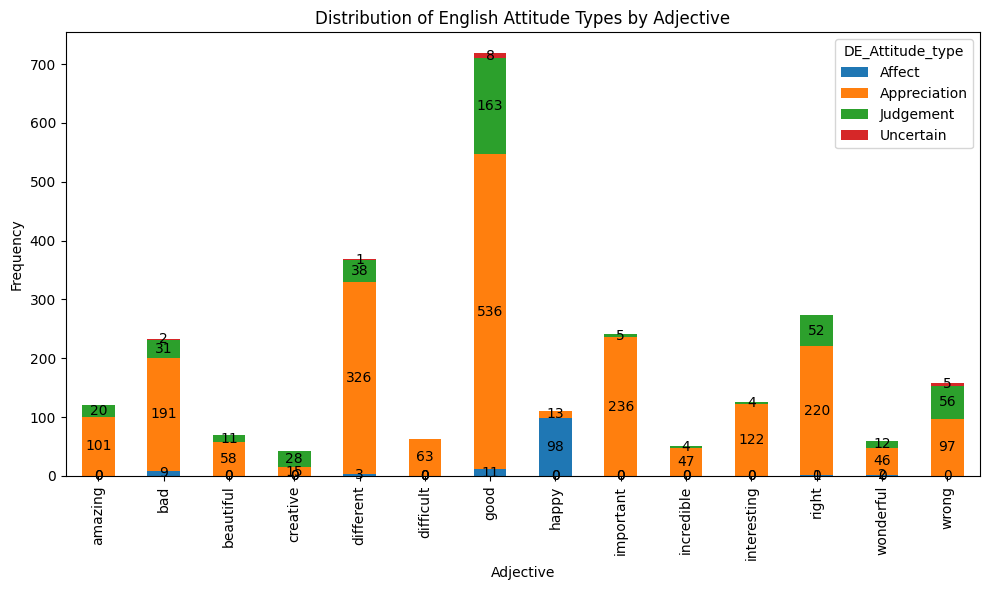

In [92]:
ax = attitude_by_adj.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel("Frequency")
plt.xlabel("Adjective")
plt.title("Distribution of English Attitude Types by Adjective")

for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center",   # puts number inside bar
        fontsize=10,
        color="black"
    )

plt.tight_layout()
plt.savefig("graph2_attitude_by_adjective.png", dpi=1200)

=== Overall DE Attitude Type Distribution ===
DE_Attitude_type  Count  Percentage
    Appreciation   2071       78.60
       Judgement    424       16.09
          Affect    124        4.71
       Uncertain     16        0.61

=== DE Attitude Type per Adjective (Raw Counts) ===
  adjective  Affect  Appreciation  Judgement  Uncertain  Total_with_DE_tag
    amazing       0           101         20          0                121
        bad       9           191         31          2                233
  beautiful       0            58         11          0                 69
   creative       0            15         28          0                 43
  different       3           326         38          1                368
  difficult       0            63          0          0                 63
       good      11           536        163          8                718
      happy      98            13          0          0                111
  important       0           236          5  

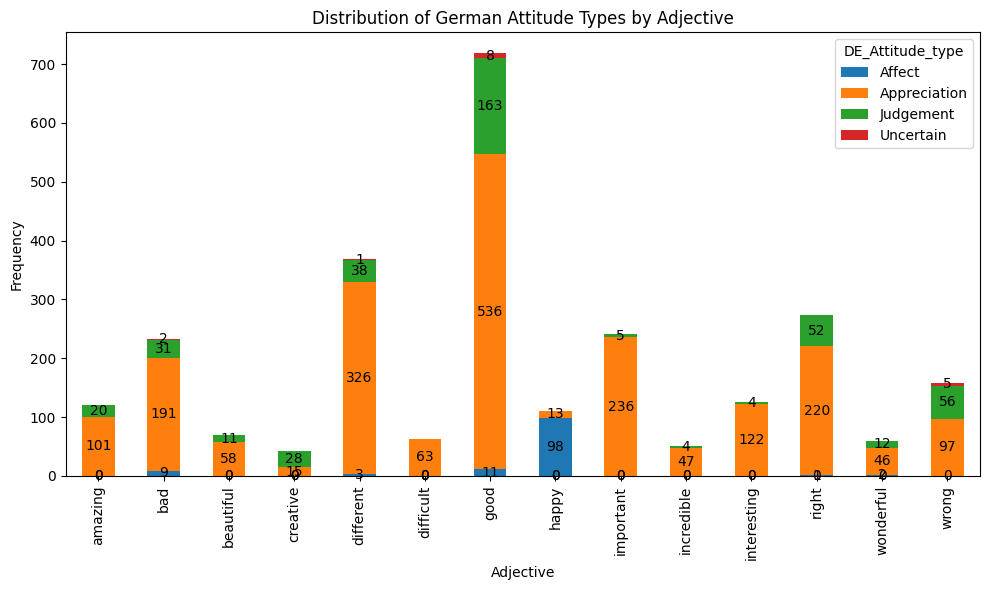

In [121]:
attitude_by_adj = pd.crosstab(
    eval_df["adjective"],
    eval_df["DE_Attitude_type"]
)

# ============================================================
# DE Attitude Type Distribution — Overall + Per Adjective
# ============================================================

# Filter: EN must be evaluative (per Mirela's instruction —
# we only care about DE translation of EN evaluative uses)
de_att_df = df[df["EN_Evaluative"] != "non-evaluative"].copy()
de_att_df = de_att_df[de_att_df["DE_Attitude_type"].notna()]

# --- TABLE: Overall DE Attitude type distribution ---
table_de_att = (
    de_att_df["DE_Attitude_type"]
    .value_counts()
    .rename_axis("DE_Attitude_type")
    .reset_index(name="Count")
)
table_de_att["Percentage"] = (
    table_de_att["Count"] / table_de_att["Count"].sum() * 100
).round(2)

print("=== Overall DE Attitude Type Distribution ===")
print(table_de_att.to_string(index=False))

# --- TABLE: DE Attitude type per adjective (raw counts) ---
de_att_per_adj = (
    de_att_df
    .groupby(["adjective", "DE_Attitude_type"])
    .size()
    .unstack(fill_value=0)
    .rename_axis(columns=None)
    .reset_index()
)
de_att_per_adj["Total_with_DE_tag"] = de_att_per_adj.drop(columns="adjective").sum(axis=1)

print("\n=== DE Attitude Type per Adjective (Raw Counts) ===")
print(de_att_per_adj.to_string(index=False))

# --- TABLE: Row percentages ---
de_att_cols = [c for c in de_att_per_adj.columns if c not in ("adjective", "Total_with_DE_tag")]
de_att_pct = de_att_per_adj[["adjective", "Total_with_DE_tag"]].copy()
for col in de_att_cols:
    de_att_pct[col + "_%"] = (
        de_att_per_adj[col] / de_att_per_adj["Total_with_DE_tag"] * 100
    ).round(1)

print("\n=== DE Attitude Type per Adjective (Row %) ===")
print(de_att_pct.to_string(index=False))


ax = attitude_by_adj.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel("Frequency")
plt.xlabel("Adjective")
plt.title("Distribution of German Attitude Types by Adjective")

for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center",   # puts number inside bar
        fontsize=10,
        color="black"
    )

plt.tight_layout()
plt.savefig("graph2_attitude_by_adjective_DE.png", dpi=1200)

In [95]:
df

,file,Domain,Gender,sent_index,token_id,token_form,token_lemma,sentence,EN_Evaluative,EN_Attitude_type,...,de_aligned_lemmas,de_sentence,DE_Evaluative,DE_Attitude_type,Translation_strategy,Translationese_effect,adjective,correction_lemma,opinion_match,EN_Eval_Binary
0,Art12_en.conllu,Art,M,35,14,different,different,"And now it 's 2010 , and there are 99 heroes f...",evaluative,Appreciation,...,NaN,Jetzt ist 2010 und es gibt 99 Helden aus 99 Lä...,non-evaluative,NaN,Alteration,Implicitation,different,NaN,False,evaluative
1,Art12_en.conllu,Art,M,60,43,different,different,And he controls them from the top down -- wher...,evaluative,Appreciation,...,NaN,Er kontrolliert sie von oben herab . Als sie s...,non-evaluative,NaN,Alteration,Implicitation,different,NaN,False,evaluative
2,Art13_en.conllu,Art,M,30,10,different,different,Fair enough . But I wanted interviews that wer...,evaluative,Appreciation,...,anders,"Schön und gut , aber ich wollte Interviews , d...",evaluative,Appreciation,Equivalence,NaN,different,NaN,True,evaluative
3,Art14_en.conllu,Art,M,44,6,different,different,It 's about mappings between different percept...,evaluative,Appreciation,...,verschieden,Es geht dabei um Verbindungen zwischen verschi...,evaluative,Appreciation,Equivalence,NaN,different,NaN,True,evaluative
4,Art14_en.conllu,Art,M,75,12,different,different,"And so I 've been beginning , with a variety o...",evaluative,Appreciation,...,verschieden,"Ich habe also angefangen , mit vielen verschie...",evaluative,Appreciation,Equivalence,NaN,different,NaN,True,evaluative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2984,Tech23_en.conllu,Tech,M,106,82,creative,creative,It would be really great if you did n't let pe...,evaluative-not_speaker,Judgement,...,kreativ,"Es wäre wirklich großartig , wenn wir aufhörte...",evaluative-not_speaker,Judgement,Equivalence,NaN,creative,NaN,True,evaluative
2985,Tech3_en.conllu,Tech,F,55,6,creative,creative,We did n't do the creative or critical thinkin...,evaluative,Appreciation,...,kritisch,Wir haben nicht kritisch und kreativ genug nac...,evaluative,Judgement,Equivalence,NaN,creative,kreativ,True,evaluative
2986,Tech9_en.conllu,Tech,F,22,31,creative,creative,What I was trying to do with tuning these horm...,non-evaluative,NaN,...,kreativ,Ich wollte eines erreichen mit dem Abstimmen d...,non-evaluative,NaN,NaN,NaN,creative,NaN,True,non-evaluative
2987,Tech9_en.conllu,Tech,F,28,14,creative,creative,"Mental images , for most of us , are central i...",non-evaluative,NaN,...,kreativ,"Mentale Bilder , für die meisten unter uns , s...",non-evaluative,NaN,NaN,NaN,creative,NaN,True,non-evaluative


# Attitude in EN and DE

In [102]:
table_attitude = pd.crosstab(
    eval_df["EN_Attitude_type"],
    eval_df["DE_Attitude_type"]
)

table_attitude

DE_Attitude_type,Affect,Appreciation,Judgement,Uncertain
EN_Attitude_type,,,,
Affect,122,0,0,0
Appreciation,2,2059,14,0
Judgement,0,11,410,0
Uncertain,0,1,0,16


In [97]:
df["attitude_match"] = (
    df["EN_Attitude_type"] == df["DE_Attitude_type"]
)

total = len(df)

mismatch_count = (~df["attitude_match"]).sum()
match_count = df["attitude_match"].sum()

mismatch_rate = mismatch_count / total
match_rate = match_count / total

print("Mismatch rate:", round(mismatch_rate, 4))
print("Match rate:", round(match_rate, 4))

Mismatch rate: 0.1268
Match rate: 0.8732


## Chi-square test (association test)
Is EN Attitude independent of DE Attitude?
* p < 0.05 → EN attitude significantly associated with DE attitude (translation is not random)
* p ≥ 0.05 → no strong evidence of systematic shift

In [103]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table_attitude)

print("Chi-square:", chi2)
print("df:", dof)
print("p-value:", p)

#translation is not random

Chi-square: 7519.520763577718
df: 9
p-value: 0.0



## Effect size
* ~0.1 = small shift
* ~0.3 = moderate shift
* ~0.5+ = strong systematic translation restructuring

In [106]:
import numpy as np

n = table_attitude.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(table_attitude.shape) - 1))
)

print("Cramér's V:", cramers_v)

Cramér's V: 0.9753132949073275


# Translation Strategy & Translationese Effects Distribution

=== Overall Translation Strategy Distribution ===
Translation_Strategy  Count  Percentage
         Equivalence   2474       89.44
          Alteration    261        9.44
                 NaN     31        1.12

=== Translationese Effects (within Alteration cases only) ===
Translationese_Effect  Count  Percentage
        Implicitation    172       65.90
        Explicitation     88       33.72
                  NaN      1        0.38

=== Translation Strategy per Adjective (Raw Counts) ===
  adjective  Alteration  Equivalence  Total
    amazing          34           89    123
        bad          22          220    242
  beautiful           3           66     69
   creative           1           42     43
  different          38          352    390
  difficult           7           56     63
       good          73          659    732
      happy           4          110    114
  important          19          228    247
 incredible           7           44     51
interesting          1

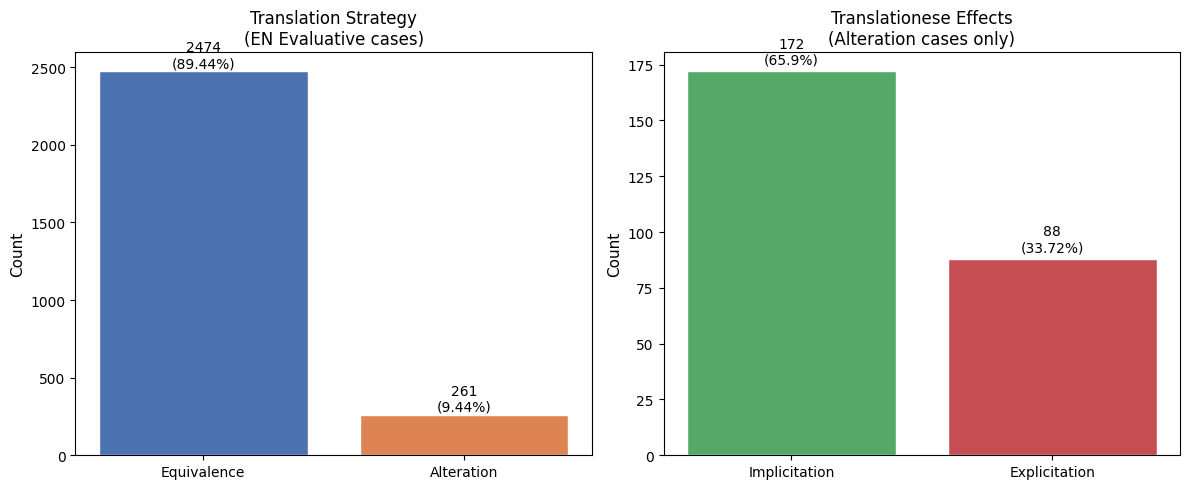

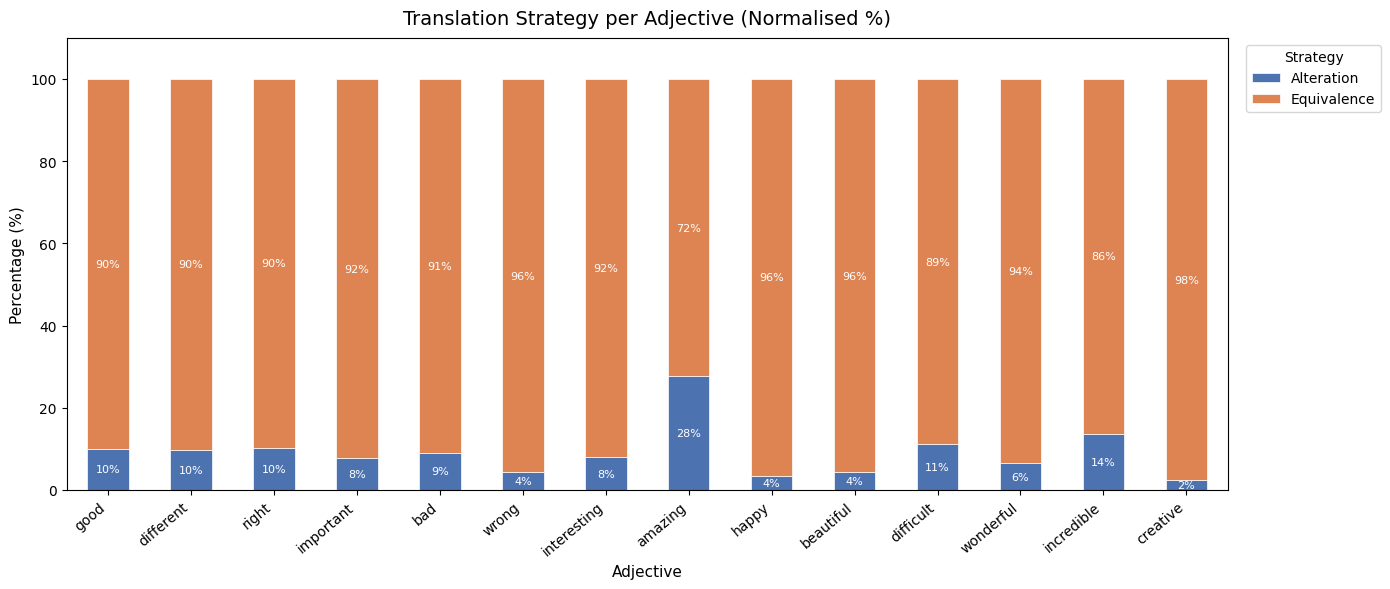

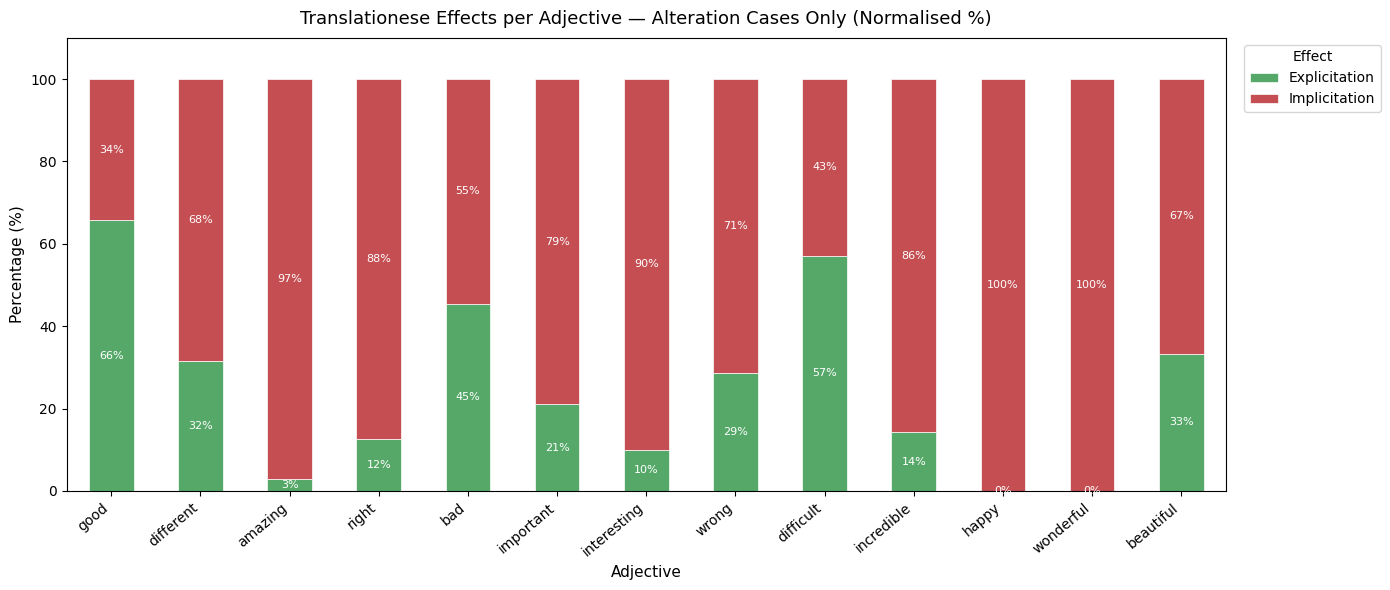

In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ts_df = df[df["EN_Evaluative"] != "non-evaluative"].copy()

# ── 1. Overall Translation Strategy (Equivalence vs Alteration) ──────────────

table_ts = (
    ts_df["Translation_strategy"]
    .value_counts(dropna=False)
    .rename_axis("Translation_Strategy")
    .reset_index(name="Count")
)
table_ts["Percentage"] = (
    table_ts["Count"] / table_ts["Count"].sum() * 100
).round(2)

print("=== Overall Translation Strategy Distribution ===")
print(table_ts.to_string(index=False))

# ── 2. Translationese Effects within Alteration cases only ───────────────────

alteration_df = ts_df[ts_df["Translation_strategy"] == "Alteration"].copy()

table_te = (
    alteration_df["Translationese_effect"]
    .value_counts(dropna=False)
    .rename_axis("Translationese_Effect")
    .reset_index(name="Count")
)
table_te["Percentage"] = (
    table_te["Count"] / table_te["Count"].sum() * 100
).round(2)

print("\n=== Translationese Effects (within Alteration cases only) ===")
print(table_te.to_string(index=False))

# ── 3. Per-adjective breakdown: Translation Strategy ─────────────────────────

ts_per_adj = (
    ts_df
    .groupby(["adjective", "Translation_strategy"])
    .size()
    .unstack(fill_value=0)
    .rename_axis(columns=None)
    .reset_index()
)
ts_per_adj["Total"] = ts_per_adj.drop(columns="adjective").sum(axis=1)

print("\n=== Translation Strategy per Adjective (Raw Counts) ===")
print(ts_per_adj.to_string(index=False))

ts_cols = [c for c in ts_per_adj.columns if c not in ("adjective", "Total")]
ts_pct = ts_per_adj[["adjective", "Total"]].copy()
for col in ts_cols:
    ts_pct[col + "_%"] = (ts_per_adj[col] / ts_per_adj["Total"] * 100).round(1)

print("\n=== Translation Strategy per Adjective (Row %) ===")
print(ts_pct.to_string(index=False))

# ── 4. Per-adjective breakdown: Translationese Effects (Alteration only) ─────

te_per_adj = (
    alteration_df
    .groupby(["adjective", "Translationese_effect"])
    .size()
    .unstack(fill_value=0)
    .rename_axis(columns=None)
    .reset_index()
)
te_per_adj["Total_Alteration"] = te_per_adj.drop(columns="adjective").sum(axis=1)

print("\n=== Translationese Effects per Adjective — Alteration cases only (Raw Counts) ===")
print(te_per_adj.to_string(index=False))

te_cols = [c for c in te_per_adj.columns if c not in ("adjective", "Total_Alteration")]
te_pct = te_per_adj[["adjective", "Total_Alteration"]].copy()
for col in te_cols:
    te_pct[col + "_%"] = (te_per_adj[col] / te_per_adj["Total_Alteration"] * 100).round(1)

print("\n=== Translationese Effects per Adjective (Row %) ===")
print(te_pct.to_string(index=False))

# ── 5. CHARTS ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart A: Overall Translation Strategy
ts_clean = table_ts[table_ts["Translation_Strategy"].notna()]
bars = axes[0].bar(
    ts_clean["Translation_Strategy"],
    ts_clean["Count"],
    color=["#4C72B0", "#DD8452"],
    edgecolor="white"
)
for bar, row in zip(bars, ts_clean.itertuples()):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{row.Count}\n({row.Percentage}%)",
        ha="center", va="bottom", fontsize=10
    )
axes[0].set_title("Translation Strategy\n(EN Evaluative cases)", fontsize=12)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_xlabel("")

# Chart B: Translationese Effects (Alteration only)
te_clean = table_te[table_te["Translationese_Effect"].notna()]
bars2 = axes[1].bar(
    te_clean["Translationese_Effect"],
    te_clean["Count"],
    color=["#55A868", "#C44E52"],
    edgecolor="white"
)
for bar, row in zip(bars2, te_clean.itertuples()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{row.Count}\n({row.Percentage}%)",
        ha="center", va="bottom", fontsize=10
    )
axes[1].set_title("Translationese Effects\n(Alteration cases only)", fontsize=12)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig("graph_translation_strategy_effects.png", dpi=300)
plt.show()

# Chart C: Normalised stacked bar — Translation Strategy per adjective
ts_plot = ts_per_adj.set_index("adjective")[ts_cols]
ts_plot = ts_plot.loc[
    ts_per_adj.set_index("adjective")["Total"].sort_values(ascending=False).index
]
ts_plot_pct = ts_plot.div(ts_plot.sum(axis=1), axis=0) * 100

ax = ts_plot_pct.plot(
    kind="bar", stacked=True, figsize=(14, 6),
    color=["#4C72B0", "#DD8452"][:len(ts_cols)],
    edgecolor="white", linewidth=0.5
)
ax.set_title("Translation Strategy per Adjective (Normalised %)", fontsize=14, pad=10)
ax.set_xlabel("Adjective", fontsize=11)
ax.set_ylabel("Percentage (%)", fontsize=11)
ax.set_xticklabels(ts_plot_pct.index, rotation=40, ha="right", fontsize=10)
ax.legend(title="Strategy", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)
ax.set_ylim(0, 110)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", label_type="center", fontsize=8, color="white")
plt.tight_layout()
plt.savefig("graph_translation_strategy_per_adjective.png", dpi=300)
plt.show()

# Chart D: Normalised stacked bar — Translationese Effects per adjective (Alteration only)
if len(te_cols) >= 2:
    te_plot = te_per_adj.set_index("adjective")[te_cols]
    te_plot = te_plot.loc[
        te_per_adj.set_index("adjective")["Total_Alteration"].sort_values(ascending=False).index
    ]
    te_plot_pct = te_plot.div(te_plot.sum(axis=1), axis=0) * 100

    ax2 = te_plot_pct.plot(
        kind="bar", stacked=True, figsize=(14, 6),
        color=["#55A868", "#C44E52"],
        edgecolor="white", linewidth=0.5
    )
    ax2.set_title("Translationese Effects per Adjective — Alteration Cases Only (Normalised %)",
                  fontsize=13, pad=10)
    ax2.set_xlabel("Adjective", fontsize=11)
    ax2.set_ylabel("Percentage (%)", fontsize=11)
    ax2.set_xticklabels(te_plot_pct.index, rotation=40, ha="right", fontsize=10)
    ax2.legend(title="Effect", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)
    ax2.set_ylim(0, 110)
    for container in ax2.containers:
        ax2.bar_label(container, fmt="%.0f%%", label_type="center", fontsize=8, color="white")
    plt.tight_layout()
    plt.savefig("graph_translationese_effects_per_adjective.png", dpi=300)
    plt.show()

##Loglinear

Poisson regression approximation of loglinear models


In [116]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ----------------------------
# 1. Clean data
# ----------------------------
df_ll = df.dropna(
    subset=[
        "EN_Attitude_type",
        "DE_Attitude_type",
        "Translation_strategy",
        "Translationese_effect",
        "Gender",
        "Domain"
    ]
).copy()

# ----------------------------
# 2. Create frequency table
# ----------------------------
freq = (
    df_ll
    .groupby([
        "EN_Attitude_type",
        "DE_Attitude_type",
        "Translation_strategy",
        "Translationese_effect",
        "Gender",
        "Domain"
    ])
    .size()
    .reset_index(name="freq")
)

# ----------------------------
# 3. Model 1 (main effects)
# ----------------------------
model_1 = smf.glm(
    formula="""
        freq ~ EN_Attitude_type
             + DE_Attitude_type
             + Translation_strategy
             + Translationese_effect
             + Gender
             + Domain
    """,
    data=freq,
    family=sm.families.Poisson()
).fit()

print("\n===== MODEL 1 SUMMARY =====\n")
print(model_1.summary())

# ----------------------------
# 4. Model 2 (interactions)
# ----------------------------
model_2 = smf.glm(
    formula="""
        freq ~ EN_Attitude_type * DE_Attitude_type
             + EN_Attitude_type * Translation_strategy
             + DE_Attitude_type * Translation_strategy
             + Translation_strategy * Translationese_effect
             + Gender
             + Domain
    """,
    data=freq,
    family=sm.families.Poisson()
).fit()

print("\n===== MODEL 2 SUMMARY =====\n")
print(model_2.summary())

# ----------------------------
# 5. Likelihood Ratio Test (correct way)
# ----------------------------
import scipy.stats as stats

lr_stat = 2 * (model_2.llf - model_1.llf)
df_diff = model_2.df_model - model_1.df_model

p_value = stats.chi2.sf(lr_stat, df_diff)

print("\n===== LR TEST =====")
print("Likelihood Ratio:", lr_stat)
print("df difference:", df_diff)
print("p-value:", p_value)

# ----------------------------
# 6. Overdispersion check (important!)
# ----------------------------
dispersion = model_1.deviance / model_1.df_resid

print("\n===== OVERDISPERSION CHECK =====")
print("Dispersion (deviance / df_resid):", dispersion)

if dispersion > 2:
    print("Strong overdispersion detected → consider Negative Binomial model")
else:
    print("Poisson assumption is reasonably OK")


===== MODEL 1 SUMMARY =====

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   freq   No. Observations:                   64
Model:                            GLM   Df Residuals:                       46
Model Family:                 Poisson   Df Model:                           17
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -107.47
Date:                Sun, 31 May 2026   Deviance:                       39.127
Time:                        22:47:02   Pearson chi2:                     40.8
No. Iterations:                     5   Pseudo R-squ. (CS):             0.4924
Covariance Type:            nonrobust                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

=== Overall DE Attitude Type Distribution ===
DE_Attitude_type  Count  Percentage
    Appreciation   2071       78.60
       Judgement    424       16.09
          Affect    124        4.71
       Uncertain     16        0.61

=== DE Attitude Type per Adjective (Raw Counts) ===
  adjective  Affect  Appreciation  Judgement  Uncertain  Total_with_DE_tag
    amazing       0           101         20          0                121
        bad       9           191         31          2                233
  beautiful       0            58         11          0                 69
   creative       0            15         28          0                 43
  different       3           326         38          1                368
  difficult       0            63          0          0                 63
       good      11           536        163          8                718
      happy      98            13          0          0                111
  important       0           236          5  

GENDER × EN ATTITUDE TYPE

Contingency Table (counts):
EN_Attitude_type  Affect  Appreciation  Judgement
Gender                                           
F                     44           949        176
M                     84          1229        262

Row percentages (%):
EN_Attitude_type  Affect  Appreciation  Judgement
Gender                                           
F                    3.8          81.2       15.1
M                    5.3          78.0       16.6

Chi-square = 5.430, df = 2, p = 0.0662
Cramér's V = 0.0445  (~0.1 small, ~0.3 moderate, ~0.5 large)

Adjusted Standardised Residuals (|> 1.96| = significant at p < .05):
EN_Attitude_type  Affect  Appreciation  Judgement
Gender                                           
F                  -1.93          2.02      -1.12
M                   1.93         -2.02       1.12


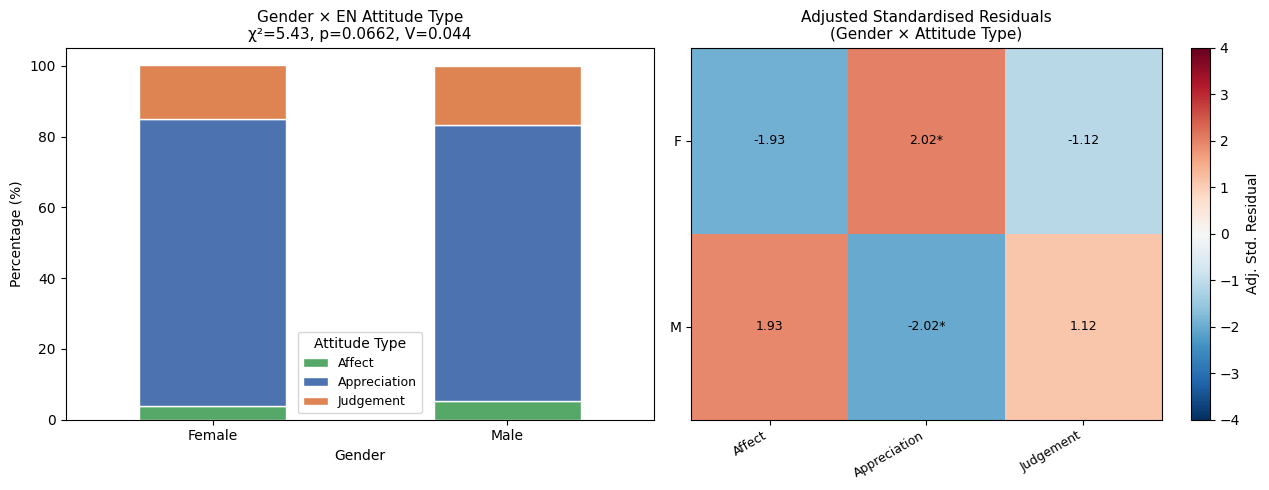


DOMAIN × EN ATTITUDE TYPE

Contingency Table (counts):
EN_Attitude_type  Affect  Appreciation  Judgement
Domain                                           
Art                    5           168         58
Bus                   27           221         40
Edu                    5           165         46
Ent                   19           174         30
His                    1           119         24
Med                   18           191         24
Phi                   11           323         55
Pol                    4           157         29
Psy                   27           201         67
Sci                    7           273         36
Tech                   4           186         29

Row percentages (%):
EN_Attitude_type  Affect  Appreciation  Judgement
Domain                                           
Art                  2.2          72.7       25.1
Bus                  9.4          76.7       13.9
Edu                  2.3          76.4       21.3
Ent                  8

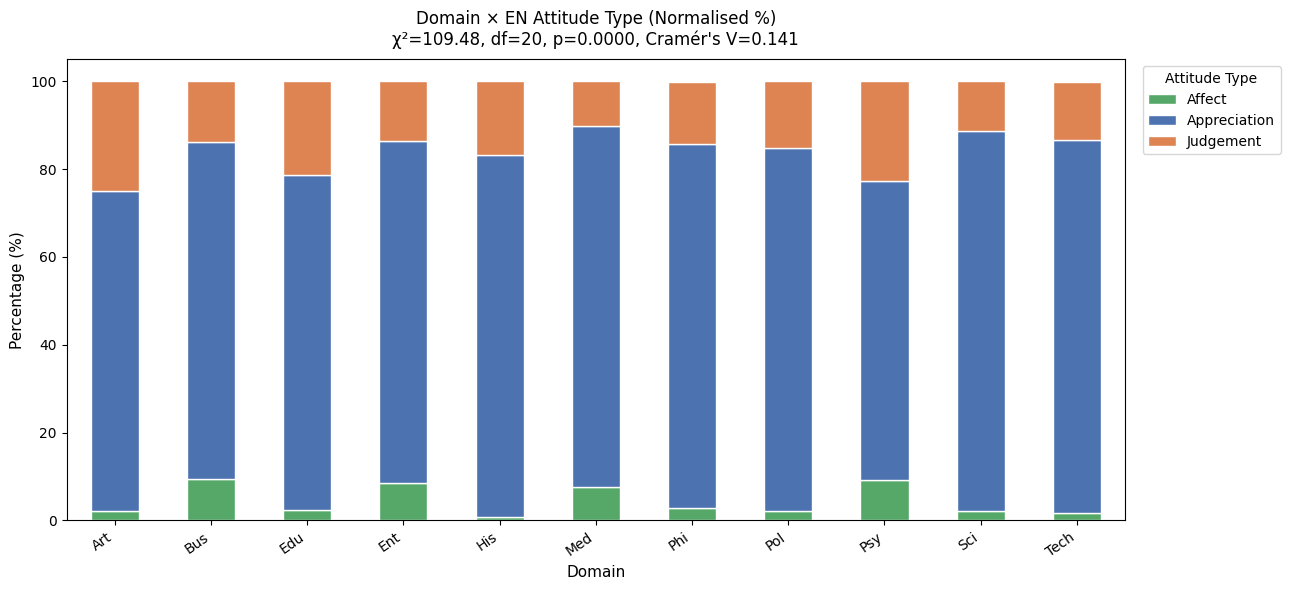

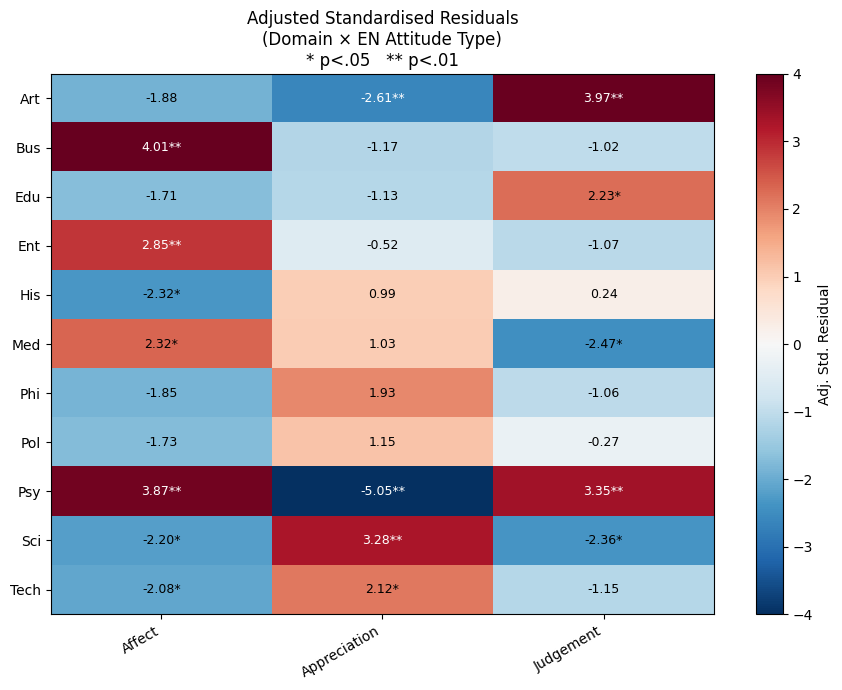


SUMMARY: Statistical Significance of Effects on EN Attitude Type
Factor  Chi-square  df  p-value  Cramér's V Significant Effect size
Gender       5.430   2   0.0662      0.0445          No       Small
Domain     109.481  20   0.0000      0.1412         Yes       Small


In [122]:
# ============================================================
# Domain & Gender Effects on EN Attitude Type
# Significance testing with chi-square + Cramér's V
# Post-hoc: adjusted standardised residuals
# ============================================================
import numpy as np
from scipy.stats import chi2_contingency

# Work from EN evaluative rows only, drop Uncertain (too few for reliable testing)
stat_df = df[
    (df["EN_Evaluative"] != "non-evaluative") &
    (df["EN_Attitude_type"].notna()) &
    (df["EN_Attitude_type"] != "Uncertain")
].copy()

def cramers_v(chi2, n, k):
    """Cramér's V effect size. k = min(rows, cols) of contingency table."""
    return np.sqrt(chi2 / (n * (k - 1)))

def adjusted_residuals(observed, expected):
    """Adjusted standardised residuals for post-hoc cell-level interpretation."""
    row_totals = observed.sum(axis=1).values[:, None]
    col_totals = observed.sum(axis=0).values[None, :]
    n = observed.values.sum()
    std_res = (observed.values - expected) / np.sqrt(
        expected
        * (1 - row_totals / n)
        * (1 - col_totals / n)
    )
    return pd.DataFrame(std_res, index=observed.index, columns=observed.columns)


# ── 1. GENDER × EN ATTITUDE TYPE ─────────────────────────────────────────────

print("=" * 60)
print("GENDER × EN ATTITUDE TYPE")
print("=" * 60)

ct_gender = pd.crosstab(stat_df["Gender"], stat_df["EN_Attitude_type"])
print("\nContingency Table (counts):")
print(ct_gender)

ct_gender_pct = ct_gender.div(ct_gender.sum(axis=1), axis=0).mul(100).round(1)
print("\nRow percentages (%):")
print(ct_gender_pct)

chi2_g, p_g, dof_g, expected_g = chi2_contingency(ct_gender)
n_g = ct_gender.values.sum()
cv_g = cramers_v(chi2_g, n_g, min(ct_gender.shape))

print(f"\nChi-square = {chi2_g:.3f}, df = {dof_g}, p = {p_g:.4f}")
print(f"Cramér's V = {cv_g:.4f}  (~0.1 small, ~0.3 moderate, ~0.5 large)")

print("\nAdjusted Standardised Residuals (|> 1.96| = significant at p < .05):")
adj_res_g = adjusted_residuals(ct_gender, expected_g)
print(adj_res_g.round(2))

# --- CHART: Gender × EN Attitude type ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ct_gender_pct.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=[colors.get(c, "#888") for c in ct_gender_pct.columns],
    edgecolor="white"
)
axes[0].set_title(f"Gender × EN Attitude Type\nχ²={chi2_g:.2f}, p={p_g:.4f}, V={cv_g:.3f}", fontsize=11)
axes[0].set_xlabel("Gender", fontsize=10)
axes[0].set_ylabel("Percentage (%)", fontsize=10)
axes[0].set_xticklabels(["Female", "Male"], rotation=0)
axes[0].legend(title="Attitude Type", fontsize=9)

# Heatmap of adjusted residuals
im = axes[1].imshow(adj_res_g.values, cmap="RdBu_r", aspect="auto", vmin=-4, vmax=4)
axes[1].set_xticks(range(len(adj_res_g.columns)))
axes[1].set_xticklabels(adj_res_g.columns, rotation=30, ha="right", fontsize=9)
axes[1].set_yticks(range(len(adj_res_g.index)))
axes[1].set_yticklabels(adj_res_g.index, fontsize=10)
axes[1].set_title("Adjusted Standardised Residuals\n(Gender × Attitude Type)", fontsize=11)
plt.colorbar(im, ax=axes[1], label="Adj. Std. Residual")

for i in range(adj_res_g.shape[0]):
    for j in range(adj_res_g.shape[1]):
        val = adj_res_g.values[i, j]
        marker = "*" if abs(val) > 1.96 else ""
        axes[1].text(j, i, f"{val:.2f}{marker}", ha="center", va="center", fontsize=9,
                     color="white" if abs(val) > 2.5 else "black")

plt.tight_layout()
plt.savefig("graph_gender_attitude_type.png", dpi=300)
plt.show()


# ── 2. DOMAIN × EN ATTITUDE TYPE ─────────────────────────────────────────────

print("\n" + "=" * 60)
print("DOMAIN × EN ATTITUDE TYPE")
print("=" * 60)

ct_domain = pd.crosstab(stat_df["Domain"], stat_df["EN_Attitude_type"])
print("\nContingency Table (counts):")
print(ct_domain)

ct_domain_pct = ct_domain.div(ct_domain.sum(axis=1), axis=0).mul(100).round(1)
print("\nRow percentages (%):")
print(ct_domain_pct)

chi2_d, p_d, dof_d, expected_d = chi2_contingency(ct_domain)
n_d = ct_domain.values.sum()
cv_d = cramers_v(chi2_d, n_d, min(ct_domain.shape))

print(f"\nChi-square = {chi2_d:.3f}, df = {dof_d}, p = {p_d:.4f}")
print(f"Cramér's V = {cv_d:.4f}  (~0.1 small, ~0.3 moderate, ~0.5 large)")

print("\nAdjusted Standardised Residuals (|> 1.96| = p < .05, |> 2.58| = p < .01):")
adj_res_d = adjusted_residuals(ct_domain, expected_d)
print(adj_res_d.round(2))

# --- CHART: Domain × EN Attitude type (normalised stacked bar) ---
fig2, ax4 = plt.subplots(figsize=(13, 6))

ct_domain_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax4,
    color=[colors.get(c, "#888") for c in ct_domain_pct.columns],
    edgecolor="white"
)
ax4.set_title(
    f"Domain × EN Attitude Type (Normalised %)\nχ²={chi2_d:.2f}, df={dof_d}, p={p_d:.4f}, Cramér's V={cv_d:.3f}",
    fontsize=12, pad=10
)
ax4.set_xlabel("Domain", fontsize=11)
ax4.set_ylabel("Percentage (%)", fontsize=11)
ax4.set_xticklabels(ct_domain_pct.index, rotation=35, ha="right", fontsize=10)
ax4.legend(title="Attitude Type", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)

plt.tight_layout()
plt.savefig("graph_domain_attitude_type.png", dpi=300)
plt.show()

# --- CHART: Adjusted residuals heatmap for domain ---
fig3, ax5 = plt.subplots(figsize=(9, 7))

im2 = ax5.imshow(adj_res_d.values, cmap="RdBu_r", aspect="auto", vmin=-4, vmax=4)
ax5.set_xticks(range(len(adj_res_d.columns)))
ax5.set_xticklabels(adj_res_d.columns, rotation=30, ha="right", fontsize=10)
ax5.set_yticks(range(len(adj_res_d.index)))
ax5.set_yticklabels(adj_res_d.index, fontsize=10)
ax5.set_title(
    "Adjusted Standardised Residuals\n(Domain × EN Attitude Type)\n* p<.05   ** p<.01",
    fontsize=12
)
plt.colorbar(im2, ax=ax5, label="Adj. Std. Residual")

for i in range(adj_res_d.shape[0]):
    for j in range(adj_res_d.shape[1]):
        val = adj_res_d.values[i, j]
        if abs(val) > 2.58:
            marker = "**"
        elif abs(val) > 1.96:
            marker = "*"
        else:
            marker = ""
        ax5.text(j, i, f"{val:.2f}{marker}", ha="center", va="center", fontsize=9,
                 color="white" if abs(val) > 2.5 else "black")

plt.tight_layout()
plt.savefig("graph_domain_attitude_residuals.png", dpi=300)
plt.show()


# ── 3. COMBINED SUMMARY TABLE ─────────────────────────────────────────────────

print("\n" + "=" * 60)
print("SUMMARY: Statistical Significance of Effects on EN Attitude Type")
print("=" * 60)
summary = pd.DataFrame([
    {
        "Factor":      "Gender",
        "Chi-square":  round(chi2_g, 3),
        "df":          dof_g,
        "p-value":     round(p_g, 4),
        "Cramér's V":  round(cv_g, 4),
        "Significant": "Yes" if p_g < 0.05 else "No",
        "Effect size": "Large" if cv_g >= 0.5 else "Moderate" if cv_g >= 0.3 else "Small"
    },
    {
        "Factor":      "Domain",
        "Chi-square":  round(chi2_d, 3),
        "df":          dof_d,
        "p-value":     round(p_d, 4),
        "Cramér's V":  round(cv_d, 4),
        "Significant": "Yes" if p_d < 0.05 else "No",
        "Effect size": "Large" if cv_d >= 0.5 else "Moderate" if cv_d >= 0.3 else "Small"
    },
])
print(summary.to_string(index=False))